In [21]:
import pandas as pd 
import numpy as np


In [22]:
data = pd.read_csv("bank-full.csv", sep=';')

In [23]:
data.isna().sum()

age          0
job          0
marital      0
education    0
default      0
balance      0
housing      0
loan         0
contact      0
day          0
month        0
duration     0
campaign     0
pdays        0
previous     0
poutcome     0
y            0
dtype: int64

ils n'y a pas de valeurs manquantes dans le dataset.

In [24]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        45211 non-null  int64 
 1   job        45211 non-null  object
 2   marital    45211 non-null  object
 3   education  45211 non-null  object
 4   default    45211 non-null  object
 5   balance    45211 non-null  int64 
 6   housing    45211 non-null  object
 7   loan       45211 non-null  object
 8   contact    45211 non-null  object
 9   day        45211 non-null  int64 
 10  month      45211 non-null  object
 11  duration   45211 non-null  int64 
 12  campaign   45211 non-null  int64 
 13  pdays      45211 non-null  int64 
 14  previous   45211 non-null  int64 
 15  poutcome   45211 non-null  object
 16  y          45211 non-null  object
dtypes: int64(7), object(10)
memory usage: 5.9+ MB


Les colonnes default, housing, loan, y sont en yes/no, mieux vaut les convertir pour le ml

In [25]:
binary_cols = ['default','housing','loan','y']
for col in binary_cols:
    data[col] = data[col].map({'yes':1, 'no':0})

In [26]:
print(data[binary_cols].head())

   default  housing  loan  y
0        0        1     0  0
1        0        1     0  0
2        0        1     1  0
3        0        1     0  0
4        0        0     0  0


In [27]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        45211 non-null  int64 
 1   job        45211 non-null  object
 2   marital    45211 non-null  object
 3   education  45211 non-null  object
 4   default    45211 non-null  int64 
 5   balance    45211 non-null  int64 
 6   housing    45211 non-null  int64 
 7   loan       45211 non-null  int64 
 8   contact    45211 non-null  object
 9   day        45211 non-null  int64 
 10  month      45211 non-null  object
 11  duration   45211 non-null  int64 
 12  campaign   45211 non-null  int64 
 13  pdays      45211 non-null  int64 
 14  previous   45211 non-null  int64 
 15  poutcome   45211 non-null  object
 16  y          45211 non-null  int64 
dtypes: int64(11), object(6)
memory usage: 5.9+ MB


on drop la colonne duration

In [28]:
data = data.drop(columns="duration")

In [29]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 16 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        45211 non-null  int64 
 1   job        45211 non-null  object
 2   marital    45211 non-null  object
 3   education  45211 non-null  object
 4   default    45211 non-null  int64 
 5   balance    45211 non-null  int64 
 6   housing    45211 non-null  int64 
 7   loan       45211 non-null  int64 
 8   contact    45211 non-null  object
 9   day        45211 non-null  int64 
 10  month      45211 non-null  object
 11  campaign   45211 non-null  int64 
 12  pdays      45211 non-null  int64 
 13  previous   45211 non-null  int64 
 14  poutcome   45211 non-null  object
 15  y          45211 non-null  int64 
dtypes: int64(10), object(6)
memory usage: 5.5+ MB


On va transformer pdays en une feature adaptée pour le machine learning et préparer le dataset pour l’entraînement. On va aussi créer une colonne binaire contacted_before pour que le modèle comprenne clairement si le client a déjà été contacté (enlever le -1).

In [30]:
data[data["pdays"]==0]

,age,job,marital,education,default,balance,housing,loan,contact,day,month,campaign,pdays,previous,poutcome,y


In [ ]:
data['contacted_before'] = (data['pdays'] != -1).astype(int)
data['pdays'] = data['pdays'].apply(lambda x: 0 if x == -1 else x)
print(data[['pdays','contacted_before']].head(10))

   pdays  contacted_before
0      0                 0
1      0                 0
2      0                 0
3      0                 0
4      0                 0
5      0                 0
6      0                 0
7      0                 0
8      0                 0
9      0                 0


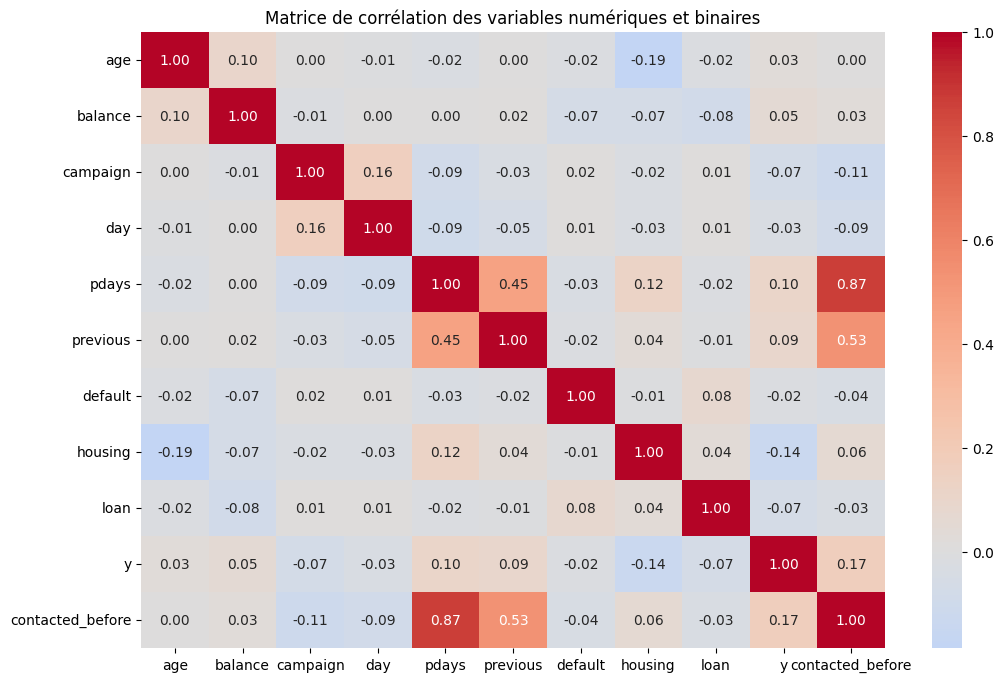

In [32]:
import matplotlib.pyplot as plt
import seaborn as sns
numeric_cols = ['age','balance','campaign','day','pdays','previous','default','housing','loan','y','contacted_before']
corr = data[numeric_cols].corr()
plt.figure(figsize=(12,8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap='coolwarm', center=0)
plt.title("Matrice de corrélation des variables numériques et binaires")
plt.show()

In [33]:
data.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,campaign,pdays,previous,poutcome,y,contacted_before
0,58,management,married,tertiary,0,2143,1,0,unknown,5,may,1,0,0,unknown,0,0
1,44,technician,single,secondary,0,29,1,0,unknown,5,may,1,0,0,unknown,0,0
2,33,entrepreneur,married,secondary,0,2,1,1,unknown,5,may,1,0,0,unknown,0,0
3,47,blue-collar,married,unknown,0,1506,1,0,unknown,5,may,1,0,0,unknown,0,0
4,33,unknown,single,unknown,0,1,0,0,unknown,5,may,1,0,0,unknown,0,0
